In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.family':'Arial'})

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

### Load mappings

In [2]:
mapping = pd.read_csv('MIDAS_VMGC_species_mapping.csv')
mapping = mapping.set_index('VMGC_species_id')

In [3]:
len(mapping.index.unique()), len(mapping['MIDAS_species_id'].unique())

(544, 391)

In [4]:
sp_mapping = mapping['MIDAS_species_id'].to_dict()

VMGC_to_MIDAS = {}
VMGC_to_species_name = {}


for v, m in sp_mapping.items():
    
    if not pd.isna(v) and not pd.isna(m):
        VMGC_to_MIDAS[int(v)] = int(m) 
        
        sp_name = mapping.loc[v]['VMGC_species']
        
        if isinstance(sp_name, pd.Series):
            sp_name = ';'.join(sp_name.unique().tolist()).strip(';')
        
        VMGC_to_species_name[int(v)] = sp_name


In [5]:
len(VMGC_to_species_name), len(VMGC_to_MIDAS)

(390, 390)

In [5]:

base_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/code/'


In [6]:
vmgc_genomes = pd.read_csv(f'{base_dir}/VMGC/VMGC_db_build/genomes.tsv', sep='\t')
vmgc_genomes['species'].unique().shape

vmgc_genome_counts = vmgc_genomes.groupby('species')['genome'].nunique()

vmgc_genome_counts_min_10 = vmgc_genome_counts[vmgc_genome_counts >= 2]
vmgc_genome_counts_min_10

species
101661      6
102208     21
105986    141
109652    104
111016      2
         ... 
987302      6
988598    856
988627    471
994737      4
998576     48
Name: genome, Length: 308, dtype: int64

### Calculate pangenome sizes per species and cluster threshold

Downloadeded these outputs from wynton

In [7]:
pangenome_counts = []
cluster_levels = [75, 80, 85, 90, 95, 99]

for v, m in VMGC_to_MIDAS.items():


    if v not in vmgc_genome_counts_min_10.index.tolist():
        continue

    vmgc_clusters = pd.read_csv(f'{base_dir}/VMGC/VMGC_db/pangenomes/{v}/clusters_99_info.tsv', sep='\t')
    midas_clusters = pd.read_csv(f'{base_dir}/GTDB/GTDB_db/pangenomes/{m}/clusters_99_info.tsv', sep='\t')
   
    vmgc_sp = VMGC_to_species_name[v]
    for c in cluster_levels:
        
        midas_count = midas_clusters[f'centroid_{c}'].unique().shape[0]
        vmgc_count = vmgc_clusters[f'centroid_{c}'].unique().shape[0]
        
        pangenome_counts += [[vmgc_sp, c,  vmgc_count, midas_count, v, m,]]
        
pangenome_counts = pd.DataFrame(pangenome_counts)
pangenome_counts.columns = ['species_name', 'cluster_level', 'VMGC_pangenome_size', 'GTDB_pangenome_size',  'VMGC_species_code', 'MIDAS_species_code']

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_14814/585837266.py:10: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  vmgc_clusters = pd.read_csv(f'{base_dir}/VMGC/VMGC_db/pangenomes/{v}/clusters_99_info.tsv', sep='\t')
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_14814/585837266.py:11: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  midas_clusters = pd.read_csv(f'{base_dir}/GTDB/GTDB_db/pangenomes/{m}/clusters_99_info.tsv', sep='\t')
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_14814/585837266.py:11: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  midas_clusters = pd.read_csv(f'{base_dir}/GTDB/GTDB_db/pangenomes/{m}/clusters_99_info.tsv', sep='\t')


### Add number of genomes that were used in each database build

In [9]:
pangenome_counts['VMGC_num_genomes'] = pangenome_counts['VMGC_species_code'].map(vmgc_genome_counts)

In [10]:
midas_md = pd.read_csv(f'{base_dir}/GTDB/MIDAS_GTDB_metadata_by_species.tsv', sep='\t')
genome_counts = midas_md.set_index('species_id')['No. clustered genomes']

pangenome_counts['MIDAS_num_genomes'] = pangenome_counts['MIDAS_species_code'].map(genome_counts)

In [11]:
pangenome_counts['larger_pangenome'] = pangenome_counts['VMGC_pangenome_size'] > pangenome_counts['GTDB_pangenome_size']
pangenome_counts['larger_pangenome'] = pangenome_counts['larger_pangenome'].replace(True, 'VMGC').replace(False, 'GTDB')

In [12]:
pangenome_counts['pangenome_size_diff'] = pangenome_counts['GTDB_pangenome_size'] - pangenome_counts['VMGC_pangenome_size']

In [13]:
pangenome_counts.to_csv('pangenome_counts.csv')

In [14]:
pangenome_counts = pd.read_csv('pangenome_counts.csv', index_col=0)
cluster_levels = [75, 80, 85, 90, 95, 99]


### Plotting pangenome size comparisons

In [15]:
pangenome_counts = pangenome_counts[pangenome_counts['VMGC_num_genomes'] >= 5]
pangenome_counts['species_name'].nunique()


129

In [16]:
pangenome_counts[pangenome_counts['cluster_level'] == 90]['larger_pangenome'].value_counts()

larger_pangenome
VMGC    85
GTDB    44
Name: count, dtype: int64

### Load MIDAS info 

In [19]:
metadata = pd.read_csv(f'{base_dir}/cervical_dysplasia/metadata/metadata.csv', index_col=0)
metadata = metadata[metadata['num_reads'] > 250000]
metadata.shape[0]

352

In [20]:
gtdb_midas = pd.read_csv(f'{base_dir}/cervical_dysplasia/MIDAS3/GTDB_ref/results_C90/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
# gtdb_midas = pd.read_csv('/Users/cdubin/Library/CloudStorage/Box-Box/PTB_shotgun/MIDAS/MIDAS3/GTDB_ref/results_min_med_marker_cov_2/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
gtdb_midas = gtdb_midas[metadata.index]
gtdb_midas = gtdb_midas >= 0.01
gtdb_midas_detected = gtdb_midas.sum(axis=1)
gtdb_detected_species = gtdb_midas_detected[gtdb_midas_detected > 0].index.tolist()
len(gtdb_detected_species)

137

In [21]:
vmgc_midas = pd.read_csv(f'{base_dir}/cervical_dysplasia/MIDAS3/VMGC_ref/results_C90/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
# vmgc_midas = pd.read_csv('/Users/cdubin/Library/CloudStorage/Box-Box/PTB_shotgun/MIDAS/MIDAS3/VMGC_ref/results_C90/merge/species/species_relative_abundance.tsv', sep='\t', index_col=0)
vmgc_midas = vmgc_midas[metadata.index]
vmgc_midas = vmgc_midas >= 0.01
vmgc_midas_detected = vmgc_midas.sum(axis=1)
vmgc_detected_species = vmgc_midas_detected[vmgc_midas_detected > 0].index.tolist()
species_prevalence = vmgc_midas_detected / vmgc_midas.shape[1]
len(vmgc_detected_species)

138

In [22]:
vmgc_detected_shared = [i for i in vmgc_detected_species if i in pangenome_counts['VMGC_species_code'].unique()]
len(vmgc_detected_shared)

86

In [23]:
gtdb_detected_shared = [i for i in gtdb_detected_species if i in pangenome_counts['MIDAS_species_code'].unique()]
len(gtdb_detected_shared)

88

In [25]:
pangenome_counts_c90 = pangenome_counts[pangenome_counts['cluster_level'] == 90]
pangenome_counts_c90[pangenome_counts_c90['VMGC_species_code'].isin(vmgc_detected_shared)]['larger_pangenome'].value_counts()

larger_pangenome
VMGC    65
GTDB    21
Name: count, dtype: int64

/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_14814/1485627888.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp['prevalence'] = temp['VMGC_species_code'].map(species_prevalence)


Lactobacillus iners
Fannyhessea vaginae
Bifidobacterium vaginale
Lactobacillus crispatus
Prevotella amnii
Dialister sp001553355
Prevotella timonensis_A
Bifidobacterium vaginale_A
Parvimonas sp001552895
Lactobacillus jensenii
Bifidobacterium vaginale_C
Sneathia sanguinegens
Prevotella sp000758925
Aerococcus christensenii
Prevotella bivia
Bifidobacterium vaginale_H
Lactobacillus gasseri
Bifidobacterium vaginale_D
Streptococcus agalactiae
Lactobacillus mulieris
Bifidobacterium vaginale_F
Prevotella disiens
Anaerococcus tetradius
Porphyromonas uenonis_A
Bifidobacterium breve
Mobiluncus curtisii
Streptococcus anginosus
Enterococcus faecalis
Stomatobaculum sp002892395
Lactobacillus paragasseri
Arcanobacterium_A sp000758825
Prevotella colorans
Porphyromonas sp001552775
Escherichia coli
Finegoldia magna_H
UBA629 sp005465875
Bifidobacterium vaginale_B
Peptoniphilus_A harei_A
Bifidobacterium sp003585735
KA00274 sp902373515
Bifidobacterium longum
Mageeibacillus indolicus
Anaerococcus lactolyticus

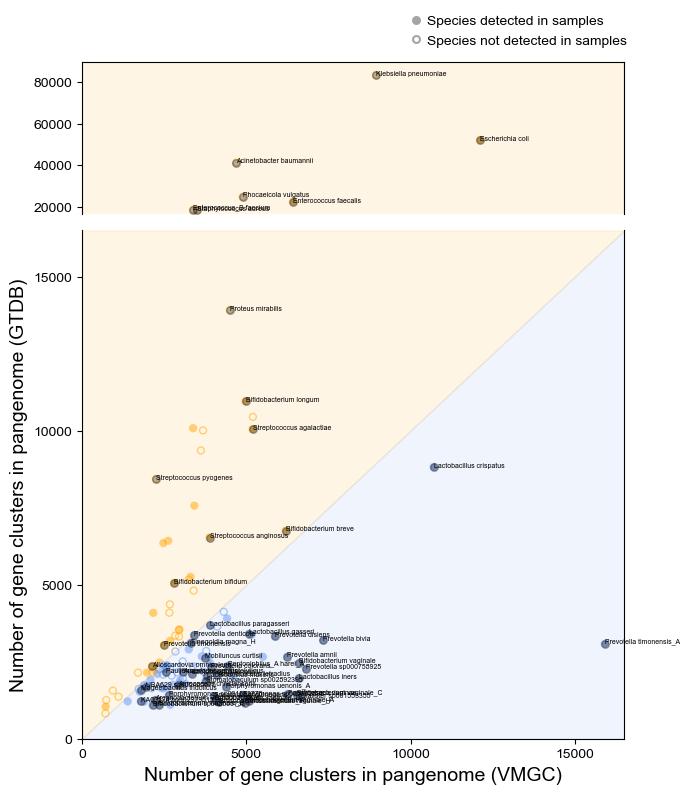

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), height_ratios=[0.3, 1], sharex=True)

c = 90

temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
temp['prevalence'] = temp['VMGC_species_code'].map(species_prevalence)

# Set limits
lims = [[0, 16500], [16500, 90000]]

for ax, lim in zip(axes.flatten()[::-1], lims):
# Shade orange ABOVE y=x (GTDB > VMGC)
    
    ax.fill_between(lim, lim, [lim[1]]*2, color='orange', alpha=0.1, zorder=0)

    # Shade blue BELOW y=x (GTDB < VMGC)
    ax.fill_between(lim, [lim[0]]*2, lim, color='cornflowerblue', alpha=0.1, zorder=0)

    # ax.plot(lim, lim, '--', alpha=0.75, zorder=1, color='lightgray')


    detected = temp[(temp['VMGC_species_code'].isin(vmgc_detected_species)) |
                    (temp['VMGC_species_code'].isin(gtdb_detected_species))]
    
    not_detected = temp[~(temp['VMGC_species_code'].isin(vmgc_detected_species)) &
                    ~(temp['VMGC_species_code'].isin(gtdb_detected_species))]

    sns.scatterplot(data=detected.sort_values('larger_pangenome'), 
                    y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
                    s=40, ax=ax, 
                    # color='dimgray', 
                    hue='larger_pangenome', palette=['orange', 'cornflowerblue', ], legend=False, 
                     alpha=0.5)
    
    sns.scatterplot(data=not_detected[not_detected['larger_pangenome'] == 'GTDB'].sort_values('larger_pangenome'), 
                y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
                s=25, ax=ax, 
                color='dimgray', 
                # hue='larger_pangenome', 

                facecolors='none', edgecolors='orange',
                # palette=['orange', 'cornflowerblue', ], 
                legend=False, 
                linewidth=1,
                alpha=0.5)
    
    sns.scatterplot(data=not_detected[not_detected['larger_pangenome'] == 'VMGC'].sort_values('larger_pangenome'), 
            y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
            s=25, ax=ax, 
            color='dimgray', 
            # hue='larger_pangenome', 

            facecolors='none', edgecolors='cornflowerblue',
            # palette=['orange', 'cornflowerblue', ], 
            legend=False, 
            linewidth=1,
            alpha=0.5)

    for _, row in temp.iterrows():

        # if row.species_name in ['Lactobacillus crispatus',
        #                         'Lactobacillus iners',
        #                         'Lactobacillus jensenii',
        #                         'Lactobacillus gasseri',
        #                         'Bifidobacterium vaginale',
        #                         'Fannyhessea vaginae']:
        diff = row.VMGC_pangenome_size / row.GTDB_pangenome_size
        if row.prevalence > 0.01 or diff >= 3 or diff <=0.33:

        # if diff > 2 or diff < 0.5 or row.prevalence > 0.05:
        # if 'Bifidobacterium vaginale' in row.species_name:
        # if row.VMGC_pangenome_size >6000 or (row.GTDB_pangenome_size<10000 and row.GTDB_pangenome_size>5000):

            # if 'Bifido' in row.species_name or 'Fanny' in row.species_name or 'Corynebacterium' in row.species_name:
            #     continue
            ax.annotate(row.species_name, (row.VMGC_pangenome_size, row.GTDB_pangenome_size), fontsize=5)
            ax.scatter(row.VMGC_pangenome_size, row.GTDB_pangenome_size, color='black', s=30, alpha=0.3)
            if lim[0] == 0:
                print(row.species_name)

    ax.set_xlim(0, 16500)
    ax.set_ylim(lim)

axes[1].set_xlabel(f'Number of gene clusters in pangenome (VMGC)', fontsize=14)
axes[1].set_ylabel(f'Number of gene clusters in pangenome (GTDB)', fontsize=14)
axes[1].set_xticks(np.arange(0,20000,5000))
axes[1].set_yticks(np.arange(0,20000,5000))


axes[0].set_ylabel('')
axes[0].set_facecolor((1.0, 0.647, 0.0, 0.1))  # RGBA for orange with alpha=0.1
axes[0].tick_params(labelbottom=False, bottom=False)


axes[0].spines[['bottom']].set_visible(False)
axes[1].spines[['top']].set_visible(False)



legend_handles = [
    Line2D([0], [0], marker='o', color='dimgray', label='Species detected in samples',linestyle='None',
           markerfacecolor='dimgray', markeredgecolor='none', markeredgewidth=1, markersize=6.5, alpha=0.6),
    Line2D([0], [0], marker='o', color='white', label='Species not detected in samples',
           markerfacecolor='white', markeredgecolor='dimgray', markeredgewidth=1.5, markersize=5, alpha=0.6)
]

axes[0].legend(
    handles=legend_handles,
    loc='center',
    ncols=1,
    columnspacing=0.9,
    frameon=False,
    fontsize=10,
    handlelength=0,
    bbox_to_anchor=[0.81,1.2]
)

plt.tight_layout()

plt.show()


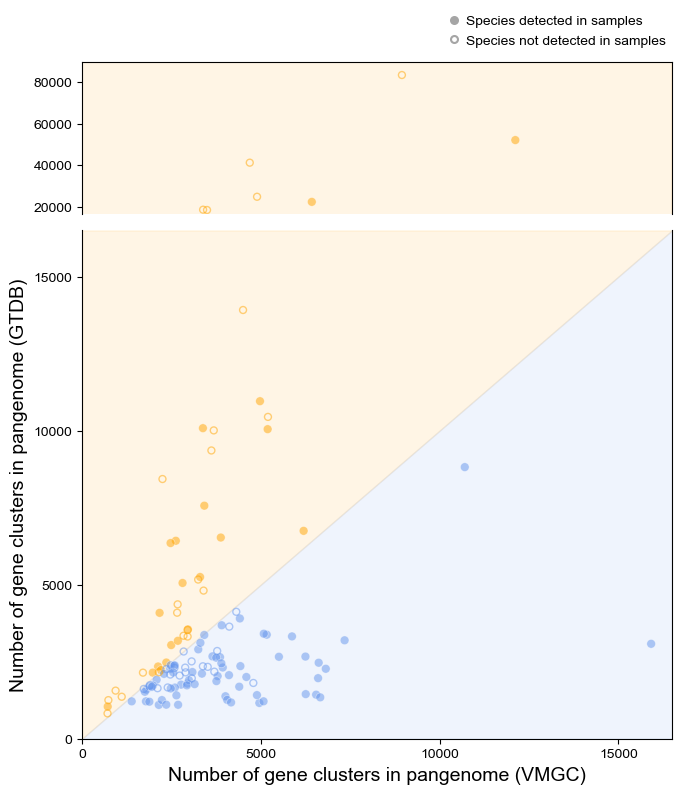

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), height_ratios=[0.3, 1], sharex=True)

c = 90

temp = pangenome_counts[pangenome_counts['cluster_level'] == c]

# Set limits
lims = [[0, 16500], [16500, 90000]]

for ax, lim in zip(axes.flatten()[::-1], lims):
# Shade orange ABOVE y=x (GTDB > VMGC)
    
    ax.fill_between(lim, lim, [lim[1]]*2, color='orange', alpha=0.1, zorder=0)

    # Shade blue BELOW y=x (GTDB < VMGC)
    ax.fill_between(lim, [lim[0]]*2, lim, color='cornflowerblue', alpha=0.1, zorder=0)

    # ax.plot(lim, lim, '--', alpha=0.75, zorder=1, color='lightgray')


    detected = temp[(temp['VMGC_species_code'].isin(vmgc_detected_species)) |
                    (temp['VMGC_species_code'].isin(gtdb_detected_species))]
    
    not_detected = temp[~(temp['VMGC_species_code'].isin(vmgc_detected_species)) &
                    ~(temp['VMGC_species_code'].isin(gtdb_detected_species))]

    sns.scatterplot(data=detected.sort_values('larger_pangenome'), 
                    y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
                    s=40, ax=ax, 
                    # color='dimgray', 
                    hue='larger_pangenome', palette=['orange', 'cornflowerblue', ], legend=False, 
                     alpha=0.5)
    
    sns.scatterplot(data=not_detected[not_detected['larger_pangenome'] == 'GTDB'].sort_values('larger_pangenome'), 
                y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
                s=25, ax=ax, 
                color='dimgray', 
                # hue='larger_pangenome', 

                facecolors='none', edgecolors='orange',
                # palette=['orange', 'cornflowerblue', ], 
                legend=False, 
                linewidth=1,
                alpha=0.5)
    
    sns.scatterplot(data=not_detected[not_detected['larger_pangenome'] == 'VMGC'].sort_values('larger_pangenome'), 
            y='GTDB_pangenome_size', x='VMGC_pangenome_size', 
            s=25, ax=ax, 
            color='dimgray', 
            # hue='larger_pangenome', 

            facecolors='none', edgecolors='cornflowerblue',
            # palette=['orange', 'cornflowerblue', ], 
            legend=False, 
            linewidth=1,
            alpha=0.5)

    # for _, row in temp.iterrows():

    #     # if row.species_name in ['Lactobacillus crispatus',
    #     #                         'Lactobacillus iners',
    #     #                         'Lactobacillus jensenii',
    #     #                         'Lactobacillus gasseri',
    #     #                         'Bifidobacterium vaginale',
    #     #                         'Fannyhessea vaginae']:

    #     if row.VMGC_pangenome_size >6000 or row.GTDB_pangenome_size>10000:

    #         if 'Staph' in row.species_name:
    #             continue
    #         ax.annotate(row.species_name, (row.VMGC_pangenome_size, row.GTDB_pangenome_size))
    #         ax.scatter(row.VMGC_pangenome_size, row.GTDB_pangenome_size, color='black', s=30)

    ax.set_xlim(0, 16500)
    ax.set_ylim(lim)

axes[1].set_xlabel(f'Number of gene clusters in pangenome (VMGC)', fontsize=14)
axes[1].set_ylabel(f'Number of gene clusters in pangenome (GTDB)', fontsize=14)
axes[1].set_xticks(np.arange(0,20000,5000))
axes[1].set_yticks(np.arange(0,20000,5000))


axes[0].set_ylabel('')
axes[0].set_facecolor((1.0, 0.647, 0.0, 0.1))  # RGBA for orange with alpha=0.1
axes[0].tick_params(labelbottom=False, bottom=False)


axes[0].spines[['bottom']].set_visible(False)
axes[1].spines[['top']].set_visible(False)



legend_handles = [
    Line2D([0], [0], marker='o', color='dimgray', label='Species detected in samples',linestyle='None',
           markerfacecolor='dimgray', markeredgecolor='none', markeredgewidth=1, markersize=6.5, alpha=0.6),
    Line2D([0], [0], marker='o', color='white', label='Species not detected in samples',
           markerfacecolor='white', markeredgecolor='dimgray', markeredgewidth=1.5, markersize=5, alpha=0.6)
]

axes[0].legend(
    handles=legend_handles,
    loc='center',
    ncols=1,
    columnspacing=0.9,
    frameon=False,
    fontsize=10,
    handlelength=0,
    bbox_to_anchor=[0.81,1.2]
)

plt.tight_layout()
fig_dir = '/Users/cdubin/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f"{fig_dir}/figure_2A.png", dpi=300)

plt.show()


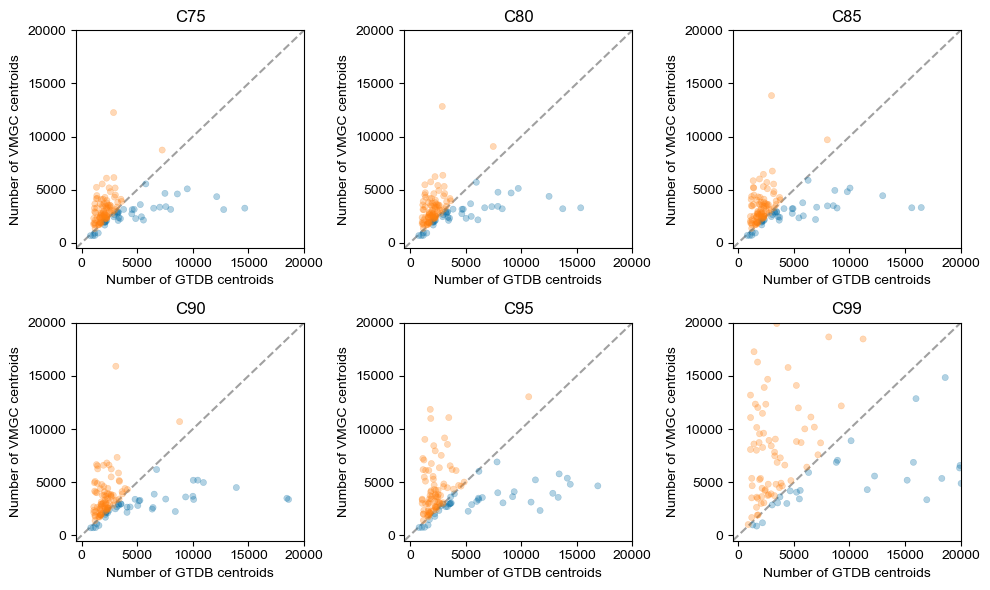

In [34]:
fig, axs = plt.subplots(2, 3, figsize=(10,6))

ax = axs.reshape(-1)


for i, c in enumerate(cluster_levels):
    
    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
    temp = temp[temp['species_name'] != 'Enterococcus faecalis']

    
    sns.scatterplot(data=temp.sort_values('larger_pangenome'), x='GTDB_pangenome_size', y='VMGC_pangenome_size', s=20, 
                    ax=ax[i], hue='larger_pangenome', legend=False, edgecolor=None, alpha=0.3)
    ax[i].set_title(f'C{c}')
    
    max_val = max(temp['GTDB_pangenome_size'].max(), temp['VMGC_pangenome_size'].max())
        
    ax[i].set_xlim(-500, 20000)
    ax[i].set_ylim(-500, 20000)

    lims = [
    np.min([ax[i].get_xlim(), ax[i].get_ylim()]),  # min of both axes
    np.max([ax[i].get_xlim(), ax[i].get_ylim()]),  # max of both axes
]

    # now plot both limits against eachother
    ax[i].plot(lims, lims, '--', alpha=0.75, zorder=0, color='gray')
    ax[i].set_xlabel('Number of GTDB centroids')
    ax[i].set_ylabel('Number of VMGC centroids')


    
plt.tight_layout()
plt.show()

In [35]:
pangenome_counts[pangenome_counts['cluster_level'] == 95].sort_values(['larger_pangenome', 'species_name']).drop(columns=['VMGC_species_code', 'MIDAS_species_code'])

,species_name,cluster_level,VMGC_pangenome_size,GTDB_pangenome_size,VMGC_num_genomes,MIDAS_num_genomes,larger_pangenome,pangenome_size_diff
718,Acinetobacter baumannii,95,4939,63965,5,4766,GTDB,59026
724,Alistipes putredinis,95,2944,3536,5,9,GTDB,592
448,Alloscardovia omnicolens,95,2340,2607,13,11,GTDB,267
442,Bifidobacterium bifidum,95,2897,5552,13,106,GTDB,2655
184,Bifidobacterium breve,95,6911,7835,82,113,GTDB,924
...,...,...,...,...,...,...,...,...
388,Streptococcus mitis_BF,95,3671,1973,17,1,VMGC,-1698
274,UBA629 sp005465875,95,2041,1777,36,8,VMGC,-264
586,Varibaculum cambriense_B,95,2968,2923,7,3,VMGC,-45
454,Varibaculum massiliense,95,4197,1910,12,1,VMGC,-2287


### Pangenome size vs. input genomes

In [32]:
pd.options.mode.chained_assignment = None  


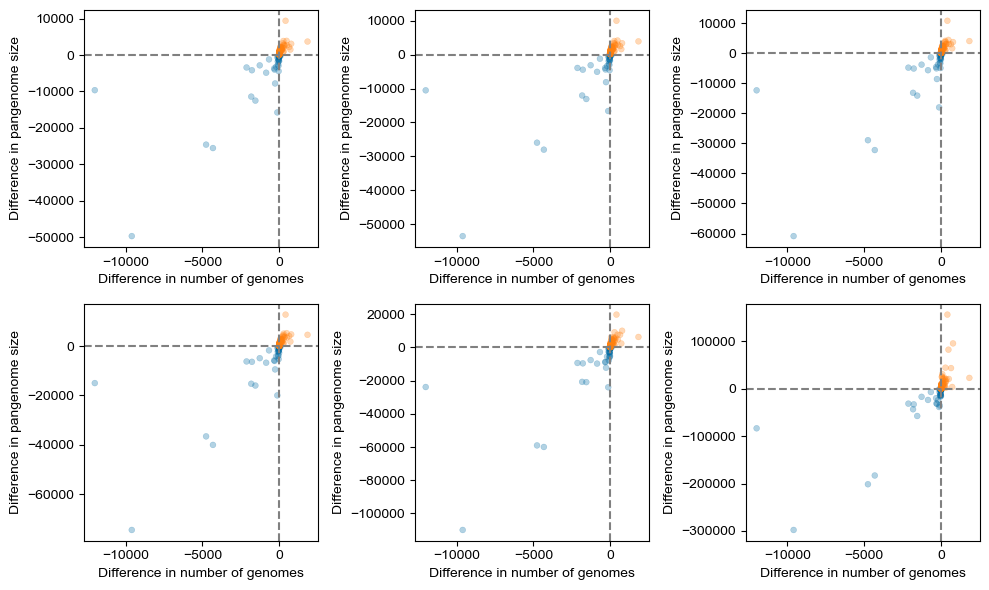

In [33]:
fig, axs = plt.subplots(2, 3, figsize=(10,6))

ax = axs.reshape(-1)

for i, c in enumerate(cluster_levels):

    temp = pangenome_counts[pangenome_counts['cluster_level'] == c]
    temp.loc[:,'num_genomes_diff'] = temp['VMGC_num_genomes']-temp['MIDAS_num_genomes']
    temp.loc[:,'pangenome_size_diff'] = temp['VMGC_pangenome_size']-temp['GTDB_pangenome_size']

    sns.scatterplot(data=temp.sort_values('larger_pangenome'), x='num_genomes_diff', y='pangenome_size_diff', 
                    hue='larger_pangenome', ax=ax[i], legend=False, edgecolor=None, alpha=0.3, size=0.2)
    
    ax[i].axvline(0, color='gray', linestyle='--')
    ax[i].axhline(0, color='gray', linestyle='--')
    
    ax[i].set_xlabel('Difference in number of genomes')
    ax[i].set_ylabel('Difference in pangenome size')


plt.tight_layout()
plt.show()

In [34]:
from scipy.stats import spearmanr
from scipy.stats import linregress

0.9237785444604508 8.685419663269243e-55


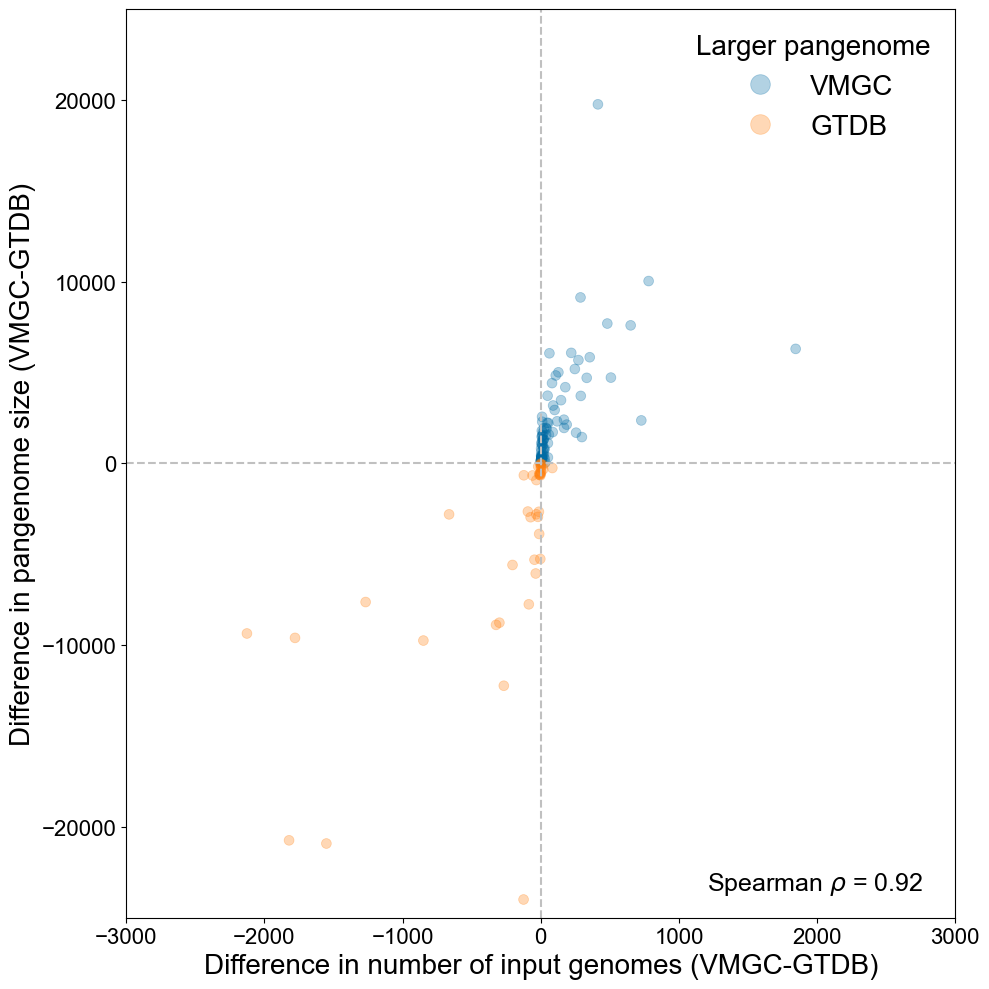

In [35]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

c = 95
temp = pangenome_counts[pangenome_counts['cluster_level'] == c]

temp.loc[:,'num_genomes_diff'] = temp['VMGC_num_genomes']-temp['MIDAS_num_genomes']
temp.loc[:,'pangenome_size_diff'] = temp['VMGC_pangenome_size']-temp['GTDB_pangenome_size']

ax.axvline(0, color='silver', linestyle='--')
ax.axhline(0, color='silver', linestyle='--')

temp = temp.rename(columns={'larger_pangenome':'Larger pangenome'})
sns.scatterplot(data=temp.sort_values('Larger pangenome', ascending=False),
                 x='num_genomes_diff', y='pangenome_size_diff', s=50,
                hue='Larger pangenome', ax=ax, legend=True, edgecolor=None, alpha=0.3)


ax.set_xlabel('Difference in number of input genomes (VMGC-GTDB)', fontsize=20)
ax.set_ylabel('Difference in pangenome size (VMGC-GTDB)',fontsize=20)

x = temp['num_genomes_diff']
y = temp['pangenome_size_diff']

slope, intercept, r_value, p_value_lin, std_err = linregress(x, y)
regression_line = slope * x + intercept

# Plot the regression line
# ax.plot(x, regression_line, color='gray', linestyle='--', alpha=0.8)

correlation_coefficient, p_value = spearmanr(x, y)
ax.annotate('Spearman ' + r'$\rho$' + f' = {round(correlation_coefficient,2)}',
                    xy=(1200,-23500), fontsize=18)
print(correlation_coefficient, p_value)

ax.set_ylim(-25000, 25000)
ax.set_xlim(-3000, 3000)
ax.tick_params(axis='both', labelsize=16) # Set x-tick label font size
plt.legend(title='Larger pangenome', fontsize=20, title_fontsize=20, frameon=False, markerscale=2)

plt.tight_layout()
plt.savefig(f'{fig_dir}/figure_S1.png', format='png', dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
temp[temp['pangenome_size_diff']<-23000]

,species_name,cluster_level,VMGC_pangenome_size,GTDB_pangenome_size,VMGC_species_code,MIDAS_species_code,VMGC_num_genomes,MIDAS_num_genomes,Larger pangenome,pangenome_size_diff,num_genomes_diff
262,Escherichia coli,95,14232,74201,166172,100009,55,4370,GTDB,-59969,-4315
418,Klebsiella pneumoniae,95,9309,119262,809727,100004,20,9621,GTDB,-109953,-9601
460,Staphylococcus aureus,95,3978,27838,423516,100002,12,12022,GTDB,-23860,-12010
640,Phocaeicola vulgatus,95,4977,28981,960341,100119,6,130,GTDB,-24004,-124
718,Acinetobacter baumannii,95,4939,63965,619896,100008,5,4766,GTDB,-59026,-4761
